<table style="width: 100%; border-style: none;">
<tr style="border-style: none">
<td style="border-style: none; width: 1%; text-align: left; font-size: 16px">Institut f&uuml;r Theoretische Physik<br /> Universit&auml;t zu K&ouml;ln</td>
<td style="border-style: none; width: 1%; font-size: 16px">&nbsp;</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 16px">Prof. Dr. Matteo Rizzi
<br />Dr. Erik Weerda</td>
</tr>
</table>
<hr>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Computerphysik</h1>
<h1 style="font-weight:bold; text-align: center; margin: 0px; font-size: 30px; padding:0px;">Übungsblatt 4</h1>
<hr>
<h3 style="font-weight:bold; text-align: center; margin: 0px; font-size: 20px; padding:0px; margin-bottom: 20px;">Sommersemester 2026</h3>
<hr>


<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Aufgaben auf Übungsblatt 4</td>
<td style="border-style: none; width: 1%; text-align: right; font-size: 15px"></td></tr></table>

- **Power Methode [1 Punkt]**
- Spektralzerlegung mit QR [1 Punkt]
- Dünnbesetzte Matrizen [1 Punkt]

<table style="border-style: none; width: 100%"><tr style="border-style: none;">
<td style="border-style: none; width: 1%; text-align: left; font-size: 25px; font-weight: bold; text-decoration: underline">Power Methode</td>


In dieser Übung werden wir die **Potenzmethode** ausnutzen. Wie Sie über den Algorithmus aus den Vorlesungen wissen, wird diese Methode verwendet, um den Eigenvektor zu finden, der dem größten Eigenwert einer Matrix entspricht. Wir beginnen mit einer Matrix $H$ und einem Startvektor $b_0$. Wir iterieren diesen Vektor unter Verwendung der Beziehung.

$$
b_{k + 1} = \dfrac{H b_k}{|H b_k|}
$$

### a) Berechnung des Eigenvektors

Betrachten Sie die folgende Matrix:
$$
H = 
\begin{pmatrix}
1 && 1 && 1 && 1 \\
1.1 && 1.2 && 1.3 && 1.4 \\
1.1 && 1.4 && 1.9  && 1.16 \\
1.1 && 1.8 && 1.27 && 1.64
\end{pmatrix}
$$

(1) Berechnen Sie die Eigenwerte und Eigenvektoren der Matrix mit der Julia-Funktion *eigen*.

In [10]:
using LinearAlgebra
using Plots
H = [
    1.0  1.0   1.0   1.0;
    1.1  1.2   1.3   1.4;
    1.1  1.4   1.9   1.16;
    1.1  1.8   1.27  1.64
]


v= [0.384649, 0.486655, 0.542354,  0.566626]

display(v)

V , R = eigen(H)








4-element Vector{Float64}:
 0.384649
 0.486655
 0.542354
 0.566626

Eigen{Float64, Float64, Matrix{Float64}, Vector{Float64}}
values:
4-element Vector{Float64}:
 -0.21728722101372147
  0.19624541288997474
  0.6127607046548779
  5.148281103468874
vectors:
4×4 Matrix{Float64}:
 -0.0498191   0.8594      0.0942349  0.384649
 -0.748967    0.0136059   0.161453   0.486655
  0.171532   -0.270966   -0.786527   0.542354
  0.638078   -0.433386    0.588582   0.566626

(2) Wählen Sie nun $b_0 = \left(1, 1, 1, 1\right)^T$ als Startvektor für die iterative Potenzmethode. 
Iterieren Sie den Startvektor gemäß der obigen Vorschrift und zeichnen Sie die Norm des Differenzvektors zwischen $b_k$ und dem entsprechenden exakten Eigenvektor als Funktion des Iterationsschritts $k$ auf.

$\textit{Note}$: Möglicherweise möchten Sie das Vorzeichen der Eigenvektoren standardisieren, bevor Sie sie vergleichen. Dies könnte beispielsweise durch Multiplizieren des Vektors mit dem Vorzeichen des ersten Eintrags erfolgen.

In [2]:
b = [1,1,1,1] / sqrt(4) # Normalised vector

errors = []

for i in 1:20
        b= (H*b)/norm(H*b)
        error1=norm(b+v)
        error2=norm(b-v)
        push!(errors, min(error1, error2))
end

In [3]:
println(errors)

Any[0.004927439059095552, 0.000213547187473639, 9.989843107443835e-6, 1.3181281998118398e-6, 7.942069976862314e-7, 7.681907241982953e-7, 7.661292914708884e-7, 7.65918934397508e-7, 7.658948651259986e-7, 7.65892044477884e-7, 7.658917100374977e-7, 7.658916702993327e-7, 7.658916655440754e-7, 7.658916649033119e-7, 7.658916650054033e-7, 7.658916648810748e-7, 7.658916649389857e-7, 7.658916649389857e-7, 7.658916649389857e-7, 7.658916649389857e-7]


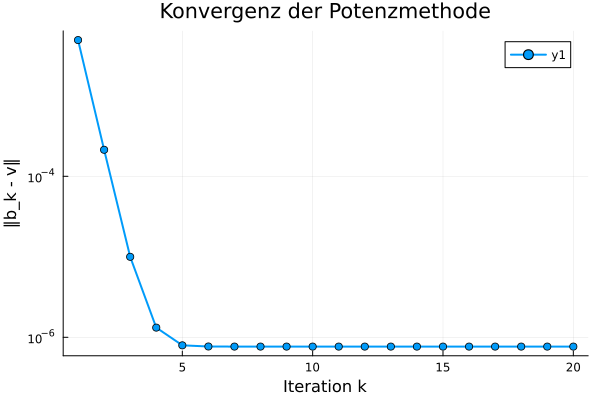

In [6]:
plot(1:20,
    errors,
    xlabel = "Iteration k",
    ylabel = "‖b_k - v‖",
    title = "Konvergenz der Potenzmethode",
    lw = 2,
    marker = :circle,
    yscale = :log10
    
)

### b) Konvergenz der Potenzmethode


Der Beweis, dass die Power-Methode funktioniert, basiert auf der Tatsache, dass $\lambda_{1} > \lambda_{2} \geq \lambda_{3} \geq ... \geq \lambda_{n}$. 
Wir wissen auch, dass der Grenzwert
$$
\lim_{k \rightarrow \infty} \boldsymbol{b}_{k} \cdot (A \boldsymbol{b}_k)
$$
zum dominanten Eigenwert $\lambda_1$ konvergiert, bzw. der Grenzwert 
$$
\lim _{k \rightarrow \infty} \frac{A^{k} \boldsymbol{b}_0}{\lambda_{1}^{k}}
$$
zum dominanten Eigenvektor $\boldsymbol{v}_1$ konvergiert (es sei denn, dass $\ldots$) konvergieren, 
aber wie schnell ist diese Konvergenz? Wovon hängt die Konvergenzgeschwindigkeit wirklich ab?

Wir wollen hier uns die Abhängigkeit der Konvergenzgeschwindigkeit vom Verhältnis $λ_{2}/λ_{1}$ anschauen. Lassen Sie uns ein numerisches Experiment erstellen, um zu sehen, wie empfindlich die Potenzmethode auf dieses Verhältnis ist.

1) Erstellen Sie eine 4 × 4-Matrix A mit dem dominanten Eigenwert $λ_{1} = 1$ und allen anderen Eigenwerten, deren absoluter Wert unter 1 liegt. Die Funktion sollte den zweiten Eigenwert $\lambda_{2}$ aufnehmen, und Sie können den dritten und den vierten Eigenwert festlegen, die kleiner als $\lambda_{2} $ sein sollten. Um es einheitlich zu machen, wählen wir $\lambda_2$ und $\lambda_3$ als 0,001 bzw. 0,0001.

$\textit{Hinweis}$: Sie können das Konzept der Ähnlichkeitstransformation verwenden ($A = PDP^{-1}$) um eine Matrix mit der gewünschten Eigenstruktur zu erstellen. Die Spalten der Matrix $P$ enthalten die Eigenvektoren von $A$ und die Diagonalmatrix $D$ enthält die Eigenwerte. Sie können $P$ als beliebige Zufallsmatrix auswählen und die Matrix $D$ steuern. 

In [11]:
function Matrix_A(lambda_2)

    # Eigenwerte
    D = Diagonal([1.0, lambda_2, 0.001, 0.0001])

    # zufällige invertierbare Matrix
    P = rand(4,4)

    # Ähnlichkeitstransformation
    A = P * D * inv(P)

    return A, lambda_2
end

Matrix_A (generic function with 1 method)

2) Wählen Sie nun mehrere Werte von $λ_2$ und erstellen Sie ein Experiment, um die Anzahl der Iterationen zu bestimmen, die erforderlich sind, damit die Potenzmethode innerhalb einer vorgegebenen Toleranz gegenüber dem dominanten Eigenvektor konvergiert.

Schließlich erstellen Sie ein Plot mit dem Verhältnis $λ_2/λ_1$ auf der horizontalen Achse und auf der vertikalen Achse die Anzahl der Iterationen, um zu einer festen Toleranz zu konvergieren. 

Können Sie das Verhalten auch analytisch erklären?

$\textit{Hinweis}$: Vergessen Sie nicht, das Vorzeichen der Vektoren zu standardisieren :)

In [13]:
i_max = 50 # maximale Anzahl von Iterationen
ratio = [] # Array für Verhältnis
i_conv = [] # Array für Iterationen, bei denen die Konvergenz stattfindet
ϵ = 1e-6 # tolerance

# Initialisieren Sie den Vektor wie zuvor
b = rand(4)
b = b/norm(b)

# Array, das λ_2 enthält. Vielleicht können Sie dieses Array besser erstellen
lambda_2_array = collect(.99: .01: .1)

for k in 1:length(lambda_2_array)
    push!(ratio, 1/lambda_2_array[k])
    
    for i in 1:i_max
        b = A*b  #EW=1
        error1 = norm(b+v)
        error2 = norm(b-v)
        error = min(error1, error2)
        if error<ϵ
            return
    end
end
end

In [ ]:
using Plots
###################
# #Schreiben Sie hier Ihre Lösung
###################

3) Können Sie erklären, warum das Plot am Ende abgeflacht wird? Wie können Sie das vermeiden? 